In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os


load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [2]:
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-latest"
)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-latest', client=<google.genai.client.Client object at 0x000002782A1F3670>, default_metadata=(), model_kwargs={})

In [3]:
llm.invoke("What is the capital of France?")

AIMessage(content=[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'Eq4BCqsBAb4+9vsCPH5OFNUvtOKX1tiMG4FJ5Mes6pHRzFgih9LBtP1dBQ0+r8fosVSqEROZg4o7qSTZh2+aRXhw8bqJ07PSc+KNs11jyIY0BTBsDRKbUdHDtnpMaa05ovjSdjlTNIAXDYahcO8dyDxkhDUXUWcU56ldzoEKhXPMVcDboLXipe2QdX/v3lhfJuX46pruXn8w8/mc3zogf4/TdiFL9aWBFuUcyGxn2Amn'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d6656-c7b8-72f2-a4d5-fecc7952cb22-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 38, 'total_tokens': 46, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 30}})

In [4]:
from typing import TypedDict,List

class graph_schema(TypedDict):
    topic:str
    insta: str
    twitter: str
    linkedin: str

In [5]:
def create_post_insta(state: graph_schema) -> graph_schema:


    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate an Instagram post
    post = llm.invoke(
        f"Write an Instagram post about {topic}. Keep the tone casual and engaging."
    ).content

    # Update the state with the generated post
    state['insta'] = post

    return {"insta": post}

def create_post_twitter(state: graph_schema) -> graph_schema:

    # Extract the topic from the state
    topic = state['topic']

    post = llm.invoke(
        f"Write an Twitter post about {topic}. Keep the tone quick."
    ).content

    # Update the state with the generated post
    state['twitter'] = post

    return {"twitter": post}

def create_post_linkedin(state: graph_schema) -> graph_schema:

    # Extract the topic from the state
    topic = state['topic']

    post = llm.invoke(
        f"Write an LinkedIn post about {topic}. Keep the tone professional."
    ).content

    # Update the state with the generated post
    state['linkedin'] = post

    return {"linkedin": post}

In [6]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

graph.add_edge(START, "create_post_insta")
graph.add_edge(START, "create_post_twitter")
graph.add_edge(START, "create_post_linkedin")

graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

parallel_graph = graph.compile()

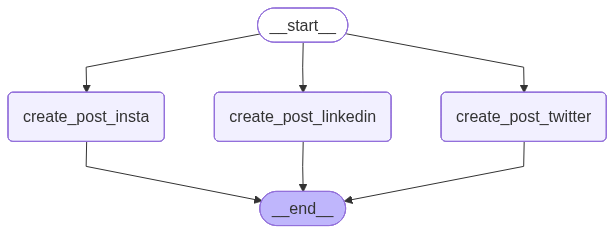

In [7]:
#Step 4 Compile the graph
from IPython.display import Image, display

Image(parallel_graph.get_graph().draw_mermaid_png())

In [8]:
parallel_graph.invoke({
    "topic": "Artificial Intelligence",
    "insta": "",
    "twitter": "",
    "linkedin": ""
})

{'topic': 'Artificial Intelligence',
 'insta': [{'type': 'text',
   'text': 'Here are a few options for your Instagram post, depending on the vibe you’re going for!\n\n### Option 1: The "Mind-Blown" Vibe (Best for a cool AI image or video)\n**Caption:**\nIs it just me, or are we officially living in the future? 🤖✨\n\nFrom generating art in seconds to having a personal assistant in my pocket, AI is definitely changing the game. It’s wild to think that things we saw in sci-fi movies a few years ago are now just… an app on our phones. 🤯\n\nI’m curious—are you embracing the AI revolution or keeping it old school? Let me know your favorite AI tool in the comments! 👇\n\n#ArtificialIntelligence #TechTrends #FutureIsNow #DigitalInnovation #AIArt #SmartTech\n\n***\n\n### Option 2: The "Productivity Hack" Vibe (Best for a screenshot or workspace photo)\n**Caption:**\nMy new favorite coworker doesn\'t drink coffee and never sleeps. ☕️💻 \n\nI’ve been diving deep into AI tools lately, and honestly?